# Modeling Supply Chains

In this example we will model the effects of the supply chain on substructure fabrication on
jacket-pile installations. For this example we will consider the following three cases:

1. Jacket installations with unlimited port storage.
2. Insufficient jacket fabrication to match installation rates.
3. Increased jacket fabrication to keep pace with installation rates.

In [1]:
from copy import deepcopy
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from ORBIT import ProjectManager, load_config
from ORBIT.phases.install import MonopileInstallation, JacketInstallation

# Set the example path for use in the docs and standalone examples usage
here = Path(".").resolve()
example_path = here.parents[1] / "examples" if here.stem == "topical_guides" else here

weather = pd.read_csv(
    example_path / "data/example_weather.csv", parse_dates=["datetime"]
).set_index("datetime")

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.


## Preparing The Cases

Here, we will load the
[`examples/configs/example_fixed_project.yaml`](https://github.com/NLRWindSystems/ORBIT/tree/main/examples/configs/example_fixed_project.yaml)
configuration and modify it to run a jacket installation process. Please note that there is no
jacket design model in ORBIT, so we must provide the basic jacket parameterizations for the
design result.

In [2]:
base_jacket_config = load_config("configs/example_fixed_project.yaml")
base_jacket_config["jacket"] = {
    "diameter": 10,
    "height": 100,
    "length": 100,
    "mass": 100,
    "deck_space": 100,
    "unit_cost": 1e6
}

slow_prod_config = deepcopy(base_jacket_config)
slow_prod_config["jacket_supply_chain"] = {
    "enabled": True,
    "substructure_delivery_time": 500,
    "num_substructures_delivered": 2,
}

increased_prod_config = deepcopy(base_jacket_config)
increased_prod_config["jacket_supply_chain"] = {
    "enabled": True,
    "substructure_delivery_time": 250,
    "num_substructures_delivered": 2,
}

case1_project = JacketInstallation(base_jacket_config, weather=weather)
case2_project = JacketInstallation(slow_prod_config, weather=weather)
case3_project = JacketInstallation(increased_prod_config, weather=weather)

case1_project.run()
case2_project.run()
case3_project.run()

FileNotFoundError: [Errno 2] No such file or directory: 'configs/example_fixed_project.yaml'

## Comparing Results

### Installation Time

In [3]:
print(f"Case 1 Installation Time: {case1_project.total_phase_time / 24:.1f} days")
print(f"Case 2 Installation Time: {case2_project.total_phase_time / 24:.1f} days")
print(f"Case 3 Installation Time: {case3_project.total_phase_time / 24:.1f} days")

NameError: name 'case1_project' is not defined

### Installation Timing

Below, we plot the timing of jacket deliveries and their subsequent installations without
considering vessel logistic delays. Note the inclement weather around the 400th day of
Case 2's installation simulation.

In [4]:
case2_df = pd.DataFrame(case2_project.env.actions)
case2_deliveries = case2_df.loc[case2_df["action"].str.contains("Delivered"), ["action", "time"]]
case2_deliveries["number"] = case2_deliveries["action"].str.split(" ").str[1].astype(int)

case2_installs = case2_df.loc[case2_df["action"].str.contains("Grout Jacket"), ["action", "time"]]
case2_installs["number"] = 1

case2_deliveries.time /= 24.0
case2_installs.time /= 24.0


case3_df = pd.DataFrame(case3_project.env.actions)
case3_deliveries = case3_df.loc[case3_df["action"].str.contains("Delivered"), ["action", "time"]]
case3_deliveries["number"] = case3_deliveries["action"].str.split(" ").str[1].astype(int)

case3_installs = case3_df.loc[case3_df["action"].str.contains("Grout Jacket"), ["action", "time"]]
case3_installs["number"] = 1

case3_deliveries.time /= 24.0
case3_installs.time /= 24.0

NameError: name 'case2_project' is not defined

NameError: name 'case2_deliveries' is not defined

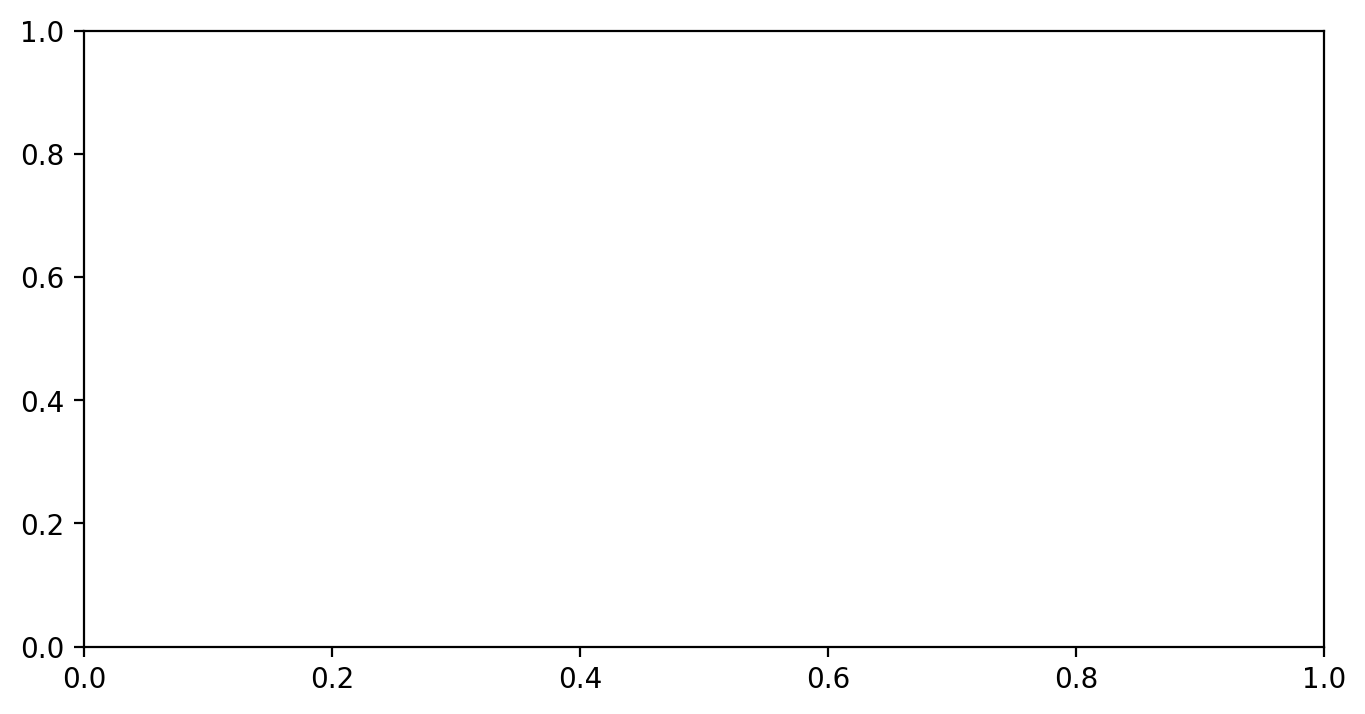

In [5]:
fig = plt.figure(figsize=(8,4), dpi=200)
ax = fig.add_subplot(111)

ax.scatter(
    case2_deliveries["time"],
    case2_deliveries["number"].cumsum(),
    marker="o",
    c="tab:blue",
    label="Substructure Delivered - Slow Fabrication"
)
ax.scatter(
    case2_installs["time"],
    case2_installs["number"].cumsum(),
    marker="x",
    c="tab:blue",
    label="Completed Installation - Slow Fabrication"
)

ax.scatter(
    case3_deliveries["time"],
    case3_deliveries["number"].cumsum(),
    marker="o",
    c="tab:orange",
    label="Substructure Delivered - Increased Fabrication"
)
ax.scatter(
    case3_installs["time"],
    case3_installs["number"].cumsum(),
    marker="x",
    c="tab:orange",
    label="Completed Installation - Increased Fabrication"
)

ax.set_xlim(0, ax.get_xlim()[1])
ax.set_ylim(0, 60)

ax.set_xlabel("Simulation Time (Days)")
ax.set_ylabel("Substructures")

ax.legend()
ax.grid()
fig.tight_layout()

### Port Storage

In [6]:
fig = plt.figure(figsize=(8,4), dpi=200)
ax = fig.add_subplot(111)

case2_installs_neg = case2_installs.copy()
case2_installs_neg["number"] *= -1
case2_total = pd.concat([case2_deliveries, case2_installs_neg]).sort_values('time')
case2_total['storage'] = case2_total['number'].cumsum()

case3_installs_neg = case3_installs.copy()
case3_installs_neg["number"] *= -1
case3_total = pd.concat([case3_deliveries, case3_installs_neg]).sort_values('time')
case3_total['storage'] = case3_total['number'].cumsum()

ax.plot(
  case2_total['time'],
  case2_total['storage'],
  label="Storage Required - Slow Fabrication"
)
ax.plot(
  case3_total['time'],
  case3_total['storage'],
  label="Storage Required - Increased Fabrication"
)

ax.set_xlim(0, ax.get_xlim()[1])
# ax.set_ylim(0, 5)

ax.axhline(4, ls="--", lw=0.5, c='k', label="Theoretical Port Storage Limit)

ax.set_xlabel("Simulation Time (h)")
ax.set_ylabel("Substructures")

ax.legend()

SyntaxError: unterminated string literal (detected at line 28) (3778338468.py, line 28)